In [ ]:
from scipy.optimize import linprog

# 1. Khai báo hệ số hàm mục tiêu (Đã nhân -1 để dùng hàm Minimize)
c = [-0.85, -1.20, -0.95, -1.35]

# 2. Khai báo ma trận hệ số của các ràng buộc bất phương trình (A_ub * x <= b_ub)
A_ub = [
    [1, 1, 1, 1],             # Ràng buộc tổng ngân sách <= 100
    [-1, 0, 0, 0],            # Ràng buộc x1 >= 25 (chuyển thành -x1 <= -25)
    [0, -1, 0, 0],            # Ràng buộc x2 >= 15 (chuyển thành -x2 <= -15)
    [0, 0, -1, 0],            # Ràng buộc x3 >= 20 (chuyển thành -x3 <= -20)
    [0, 0, 0, -1],            # Ràng buộc x4 >= 10 (chuyển thành -x4 <= -10)
    [0.35, -0.65, 0.35, -0.65] # Ràng buộc tỷ trọng công nghệ chiến lược
]

# 3. Khai báo vector giới hạn của các ràng buộc
b_ub = [100, -25, -15, -20, -10, 0]

# 4. Giải bài toán tối ưu
res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=[(0, None)]*4, method='highs')

# 5. In báo cáo kết quả
if res.success:
    print("--- KẾT QUẢ TỐI ƯU PHÂN BỔ NGÂN SÁCH ---")
    print(f"Tổng GDP kỳ vọng tăng thêm (Z*): {-res.fun:.2f} nghìn tỷ VND")
    print("\nPhân bổ tối ưu từng hạng mục:")
    print(f"1. Hạ tầng số (x1): {res.x[0]:.2f} nghìn tỷ VND")
    print(f"2. AI và dữ liệu (x2): {res.x[1]:.2f} nghìn tỷ VND")
    print(f"3. Nhân lực số (x3): {res.x[2]:.2f} nghìn tỷ VND")
    print(f"4. R&D công nghệ (x4): {res.x[3]:.2f} nghìn tỷ VND")
else:
    print("Không tìm thấy giải pháp tối ưu. Lỗi:", res.message)

--- KẾT QUẢ TỐI ƯU PHÂN BỔ NGÂN SÁCH ---
Tổng GDP kỳ vọng tăng thêm (Z*): 112.25 nghìn tỷ VND

Phân bổ tối ưu từng hạng mục:
1. Hạ tầng số (x1): 25.00 nghìn tỷ VND
2. AI và dữ liệu (x2): 15.00 nghìn tỷ VND
3. Nhân lực số (x3): 20.00 nghìn tỷ VND
4. R&D công nghệ (x4): 40.00 nghìn tỷ VND


In [ ]:
import pulp

# 1. Khởi tạo bài toán Tối đa hóa (Maximize)
prob = pulp.LpProblem("Toi_uu_Ngan_sach_So", pulp.LpMaximize)

# 2. Khai báo các biến quyết định
x1 = pulp.LpVariable("x1_Ha_tang", lowBound=0)
x2 = pulp.LpVariable("x2_AI", lowBound=0)
x3 = pulp.LpVariable("x3_Nhan_luc", lowBound=0)
x4 = pulp.LpVariable("x4_RnD", lowBound=0)

# 3. Định nghĩa Hàm mục tiêu (Maximize GDP growth)
prob += 0.85*x1 + 1.20*x2 + 0.95*x3 + 1.35*x4, "Tong_GDP_gain"

# 4. Định nghĩa các Ràng buộc
prob += x1 + x2 + x3 + x4 <= 100, "Ngan_sach_tong"
prob += x1 >= 25, "Toi_thieu_Ha_tang"
prob += x2 >= 15, "Toi_thieu_AI"
prob += x3 >= 20, "Toi_thieu_Nhan_luc"
prob += x4 >= 10, "Toi_thieu_RnD"
# Ràng buộc: (x2 + x4) / Total >= 0.35 => x2 + x4 >= 0.35 * (x1 + x2 + x3 + x4)
prob += x2 + x4 >= 0.35 * (x1 + x2 + x3 + x4), "Ty_trong_Cong_nghe_chien_luoc"

# 5. Giải bài toán
prob.solve()

# 6. In kết quả
print(f"Trạng thái giải: {pulp.LpStatus[prob.status]}")
print(f"Tổng GDP kỳ vọng tăng thêm (Z*): {pulp.value(prob.objective):.2f} nghìn tỷ VND\n")

print("--- Phân bổ tối ưu ---")
for var in prob.variables():
    print(f"{var.name}: {var.varValue:.2f} nghìn tỷ VND")

# 7. In Shadow Prices
print("\n--- Giá đối ngẫu (Shadow Prices) ---")
for name, constraint in prob.constraints.items():
    print(f"Ràng buộc '{name}': {constraint.pi:.2f}")

Trạng thái giải: Optimal
Tổng GDP kỳ vọng tăng thêm (Z*): 112.25 nghìn tỷ VND

--- Phân bổ tối ưu ---
x1_Ha_tang: 25.00 nghìn tỷ VND
x2_AI: 15.00 nghìn tỷ VND
x3_Nhan_luc: 20.00 nghìn tỷ VND
x4_RnD: 40.00 nghìn tỷ VND

--- Giá đối ngẫu (Shadow Prices) ---
Ràng buộc 'Ngan_sach_tong': 1.35
Ràng buộc 'Toi_thieu_Ha_tang': -0.50
Ràng buộc 'Toi_thieu_AI': -0.15
Ràng buộc 'Toi_thieu_Nhan_luc': -0.40
Ràng buộc 'Toi_thieu_RnD': -0.00
Ràng buộc 'Ty_trong_Cong_nghe_chien_luoc': -0.00


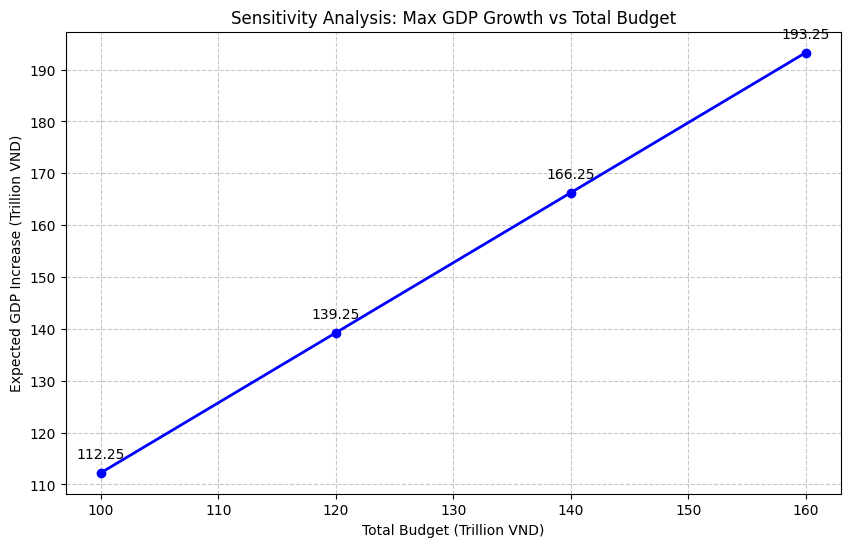

In [ ]:
import pulp
import matplotlib.pyplot as plt

# 1. Function to solve the allocation problem for a given budget B
def solve_budget_allocation(B):
    prob = pulp.LpProblem("Sensitivity_Analysis", pulp.LpMaximize)
    x1 = pulp.LpVariable("x1", lowBound=0)
    x2 = pulp.LpVariable("x2", lowBound=0)
    x3 = pulp.LpVariable("x3", lowBound=0)
    x4 = pulp.LpVariable("x4", lowBound=0)

    prob += 0.85*x1 + 1.20*x2 + 0.95*x3 + 1.35*x4

    # Constraints
    prob += x1 + x2 + x3 + x4 <= B
    prob += x1 >= 25
    prob += x2 >= 15
    prob += x3 >= 20
    prob += x4 >= 10
    prob += x2 + x4 >= 0.35 * (x1 + x2 + x3 + x4)

    # Solve without log output
    prob.solve(pulp.PULP_CBC_CMD(msg=False))
    return pulp.value(prob.objective)

# 2. Run analysis for different budget levels
budgets = [100, 120, 140, 160]
z_values = [solve_budget_allocation(b) for b in budgets]

# 3. Visualization
plt.figure(figsize=(10, 6))
plt.plot(budgets, z_values, marker='o', color='b', linewidth=2)
plt.title('Sensitivity Analysis: Max GDP Growth vs Total Budget')
plt.xlabel('Total Budget (Trillion VND)')
plt.ylabel('Expected GDP Increase (Trillion VND)')
plt.grid(True, linestyle='--', alpha=0.7)

for i, txt in enumerate(z_values):
    plt.annotate(f"{txt:.2f}", (budgets[i], z_values[i]), textcoords="offset points", xytext=(0,10), ha='center')

plt.show()

In [ ]:
import pulp

# 1. Khởi tạo bài toán Maximize
prob = pulp.LpProblem("Toi_uu_Uu_tien_Nhan_luc", pulp.LpMaximize)

# 2. Khai báo biến
x1 = pulp.LpVariable("x1_Ha_tang", lowBound=0)
x2 = pulp.LpVariable("x2_AI", lowBound=0)
x3 = pulp.LpVariable("x3_Nhan_luc", lowBound=0)
x4 = pulp.LpVariable("x4_RnD", lowBound=0)

# 3. Hàm mục tiêu
prob += 0.85*x1 + 1.20*x2 + 0.95*x3 + 1.35*x4, "Tong_GDP_gain"

# 4. Các ràng buộc (Đã cập nhật ràng buộc nhân lực số lên 30)
prob += x1 + x2 + x3 + x4 <= 100, "Ngan_sach_tong"
prob += x1 >= 25, "Toi_thieu_Ha_tang"
prob += x2 >= 15, "Toi_thieu_AI"
prob += x3 >= 30, "Toi_thieu_Nhan_luc_MOI"  # Tăng từ 20 lên 30
prob += x4 >= 10, "Toi_thieu_RnD"
prob += x2 + x4 >= 0.35 * (x1 + x2 + x3 + x4), "Ty_trong_Cong_nghe"

# 5. Giải bài toán
prob.solve(pulp.PULP_CBC_CMD(msg=False))

# 6. In kết quả
print(f"Trạng thái giải: {pulp.LpStatus[prob.status]}")
if prob.status == pulp.LpStatusOptimal:
    print(f"Tổng GDP kỳ vọng tăng thêm (Z* mới): {pulp.value(prob.objective):.2f} nghìn tỷ VND\n")
    print("--- Phân bổ tối ưu mới ---")
    for var in prob.variables():
        print(f"{var.name} = {var.varValue:.2f} nghìn tỷ VND")

Trạng thái giải: Optimal
Tổng GDP kỳ vọng tăng thêm (Z* mới): 108.25 nghìn tỷ VND

--- Phân bổ tối ưu mới ---
x1_Ha_tang = 25.00 nghìn tỷ VND
x2_AI = 15.00 nghìn tỷ VND
x3_Nhan_luc = 30.00 nghìn tỷ VND
x4_RnD = 30.00 nghìn tỷ VND
